# derived_8.0-optimization-1.0

This notebook evaluates the generalization of features and hyperparameters found on derived_8.2 (the Washington-only split) when applied to the older derived_8.0 dataset.

## 1. Imports and Environment Setup

In this section, we import the required libraries (pandas, numpy, xgboost, scikit-learn, and matplotlib) and set up the random seeds to ensure full reproducibility of the training and evaluation steps.

In [1]:
import os
import sys
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

# Define random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print(f"Imports loaded. Random seed set to {SEED}. Using device: {XGB_DEVICE}")


XGBoost CUDA support verified and enabled.
Imports loaded. Random seed set to 42. Using device: cuda


## 2. Project Path Setup

Here, we dynamically locate the project root containing the data folder and set up directory paths for importing the pipeline, loading the splits, and saving results.

In [2]:
def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
SPLIT_ROOT = DATA_ROOT / "splits"
OUT_DIR = PROJECT_ROOT / "notebooks/experiment/derived_8.0-optimization-1.0"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Add project root to sys.path so we can import modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Also import u_dashboard metrics_dashboard
from u_dashboard.dashboard import metrics_dashboard

print("Project Paths Resolved:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUT_DIR:      {OUT_DIR}")

Project Paths Resolved:
  PROJECT_ROOT: C:\Users\pan\Documents\GitHub\MDR-Project
  DATA_ROOT:    C:\Users\pan\Documents\GitHub\MDR-Project\data
  SPLIT_ROOT:   C:\Users\pan\Documents\GitHub\MDR-Project\data\splits
  OUT_DIR:      C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.0-optimization-1.0


## 3. Load Dataset Splits

In this section, we load the training, validation, and testing splits for `derived_8.0` directly from the split root path. We print the shape of each split and check for common stations to ensure alignment.

In [3]:
train_path = SPLIT_ROOT / "derived_8.0/train.csv"
val_path   = SPLIT_ROOT / "derived_8.0/val.csv"
test_path  = SPLIT_ROOT / "derived_8.0/test.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print("Loaded splits:")
print(f"  train: {train_df.shape} (stations: {train_df['station_id'].nunique()})")
print(f"  val:   {val_df.shape} (stations: {val_df['station_id'].nunique()})")
print(f"  test:  {test_df.shape} (stations: {test_df['station_id'].nunique()})")

Loaded splits:
  train: (6868, 499) (stations: 5)
  val:   (2720, 499) (stations: 4)
  test:  (4016, 499) (stations: 5)


## 4. Define Feature Sets (Old vs New)

Here, we define:
1. The **Old Feature Set** (38 features) extracted from the baseline `MDR-v25.ipynb` notebook.
2. The **New Feature Set** (50 features) generated by the feature selection pipeline on the `derived_8.0` training split.

In [4]:
FEATURE_SET_OLD = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_ema_G_API_kobs7',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
]

# Load new feature set from JSON
selected_features_path = OUT_DIR / "selected_features.json"
with open(selected_features_path, "r", encoding="utf-8") as f:
    FEATURE_SET_NEW = json.load(f)

print(f"Old Feature Set: {len(FEATURE_SET_OLD)} features")
print(f"New Feature Set: {len(FEATURE_SET_NEW)} features")

Old Feature Set: 38 features
New Feature Set: 50 features


## 5. Prepare Target and Temporal Decay Weights

We prepare the inputs for training and evaluation:
1. Concatenate `train_df` and `val_df` into a unified `trainval_df` split, which matches the training split strategy used in baseline models.
2. Add `year` and `month` columns derived from the `date` column.
3. Compute the temporal decay weights `w_trainval` (representing the temporal drift weights) using `beta = 0.2` relative to the maximum year in the training dataset.

In [5]:
TARGET_COL = "soil_moisture_5cm"

# Concatenate train and val splits
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

# Extract year and month columns
trainval_df["date"] = pd.to_datetime(trainval_df["date"], errors="coerce")
trainval_df["year"] = trainval_df["date"].dt.year.astype(float)
trainval_df["month"] = trainval_df["date"].dt.month.astype(float)

test_df["date"] = pd.to_datetime(test_df["date"], errors="coerce")
test_df["year"] = test_df["date"].dt.year.astype(float)
test_df["month"] = test_df["date"].dt.month.astype(float)

# Compute temporal weights
max_year = trainval_df["year"].max()
beta = 0.2
w_trainval = np.exp(beta * (trainval_df["year"] - max_year))
# Normalize weights so that mean is 1.0
w_trainval = w_trainval / w_trainval.mean()
w_trainval = np.asarray(w_trainval).ravel()

print("Weight Stats for trainval:")
w_series = pd.Series(w_trainval)
print(w_series.describe())
print(f"  Min year ({trainval_df['year'].min()}) mean weight: {w_series[trainval_df['year'] == trainval_df['year'].min()].mean():.4f}")
print(f"  Max year ({max_year}) mean weight: {w_series[trainval_df['year'] == max_year].mean():.4f}")

Weight Stats for trainval:
count    9588.000000
mean        1.000000
std         0.336108
min         0.591030
25%         0.721885
50%         0.881713
75%         1.315361
max         1.606585
dtype: float64
  Min year (2017.0) mean weight: 0.5910
  Max year (2022.0) mean weight: 1.6066


## 6. Helper Metric Functions and Models Configurations

In this section, we define the standard performance evaluation function `compute_metrics` that computes metrics like $R^2$, RMSE, ubRMSE, Bias, and MAE.
We also define the 8 model configurations corresponding to all combinations of:
- Temporal weighting (`w/ Drift` vs `w/o Drift`)
- Feature set (`Old` vs `New`)
- Hyperparameters (`Old` vs `New`)

In [6]:
def compute_metrics(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    
    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    ubrmse = float(np.std(err))
    
    return {
        f"{prefix}R2": r2,
        f"{prefix}RMSE": rmse,
        f"{prefix}ubRMSE": ubrmse,
        f"{prefix}Bias": bias,
        f"{prefix}MAE": mae,
        f"{prefix}Med|Err|": float(np.median(ae)),
        f"{prefix}Pearson": float(np.corrcoef(y_true, y_pred)[0, 1]) if len(y_true) > 1 and np.std(y_pred) > 0 else 0.0
    }

# Define models configuration
# Old HParams (from MDR-v25): LR=0.04, Est=5500, MCW=2
# New HParams (from winning 8.2 SOTA): LR=0.01, Est=1500, MCW=10
MODELS_CONFIG = [
    {
        "id": 0,
        "name": "w/o Drift, Old Feats, Old HParams",
        "features": "old",
        "weighted": False,
        "hparams": {
            "objective": "reg:absoluteerror",  # MAE for unweighted old params
            "learning_rate": 0.04,
            "n_estimators": 5500,
            "max_depth": 8,
            "min_child_weight": 2,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03,
            "gamma": 0.0
        }
    },
    {
        "id": 1,
        "name": "w/o Drift, Old Feats, New HParams",
        "features": "old",
        "weighted": False,
        "hparams": {
            "objective": "reg:squarederror",  # MSE for new winning params
            "learning_rate": 0.01,
            "n_estimators": 1500,
            "max_depth": 8,
            "min_child_weight": 10,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03
        }
    },
    {
        "id": 2,
        "name": "w/o Drift, New Feats, Old HParams",
        "features": "new",
        "weighted": False,
        "hparams": {
            "objective": "reg:absoluteerror",
            "learning_rate": 0.04,
            "n_estimators": 5500,
            "max_depth": 8,
            "min_child_weight": 2,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03,
            "gamma": 0.0
        }
    },
    {
        "id": 3,
        "name": "w/o Drift, New Feats, New HParams",
        "features": "new",
        "weighted": False,
        "hparams": {
            "objective": "reg:squarederror",
            "learning_rate": 0.01,
            "n_estimators": 1500,
            "max_depth": 8,
            "min_child_weight": 10,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03
        }
    },
    {
        "id": 4,
        "name": "w/ Drift, Old Feats, Old HParams",
        "features": "old",
        "weighted": True,
        "hparams": {
            "objective": "reg:pseudohubererror",  # Pseudo-Huber for weighted old params
            "learning_rate": 0.04,
            "n_estimators": 5500,
            "max_depth": 8,
            "min_child_weight": 2,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03,
            "gamma": 0.0
        }
    },
    {
        "id": 5,
        "name": "w/ Drift, Old Feats, New HParams",
        "features": "old",
        "weighted": True,
        "hparams": {
            "objective": "reg:squarederror",
            "learning_rate": 0.01,
            "n_estimators": 1500,
            "max_depth": 8,
            "min_child_weight": 10,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03
        }
    },
    {
        "id": 6,
        "name": "w/ Drift, New Feats, Old HParams",
        "features": "new",
        "weighted": True,
        "hparams": {
            "objective": "reg:pseudohubererror",
            "learning_rate": 0.04,
            "n_estimators": 5500,
            "max_depth": 8,
            "min_child_weight": 2,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03,
            "gamma": 0.0
        }
    },
    {
        "id": 7,
        "name": "w/ Drift, New Feats, New HParams",
        "features": "new",
        "weighted": True,
        "hparams": {
            "objective": "reg:squarederror",
            "learning_rate": 0.01,
            "n_estimators": 1500,
            "max_depth": 8,
            "min_child_weight": 10,
            "subsample": 0.9,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.5,
            "reg_alpha": 0.03
        }
    }
]

print("Model configurations initialized:")
for m in MODELS_CONFIG:
    print(f"  Model {m['id']}: {m['name']}")

Model configurations initialized:
  Model 0: w/o Drift, Old Feats, Old HParams
  Model 1: w/o Drift, Old Feats, New HParams
  Model 2: w/o Drift, New Feats, Old HParams
  Model 3: w/o Drift, New Feats, New HParams
  Model 4: w/ Drift, Old Feats, Old HParams
  Model 5: w/ Drift, Old Feats, New HParams
  Model 6: w/ Drift, New Feats, Old HParams
  Model 7: w/ Drift, New Feats, New HParams


## 7. Model Training and Predictions

In this section, we train all 8 models on `trainval_df` using the selected feature set (Old vs New), optional sample weights (temporal decay drift weights), and the corresponding hyperparameters. We evaluate their loss curves at each boosting round, save the models, and collect overall and yearly test predictions.

In [7]:
trained_models = {}
evals_results = {}
metrics_list = []
yearly_metrics_list = []

# Prepare DataFrame to hold predictions
test_predictions_df = test_df[["date", "year", "month", TARGET_COL]].copy()

models_dir = OUT_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)

print("Starting training loop for 8 configurations...\n")
for config in MODELS_CONFIG:
    model_id = config["id"]
    model_name = config["name"]
    feat_type = config["features"]
    weighted = config["weighted"]
    
    # Select feature set
    feature_cols = FEATURE_SET_OLD if feat_type == "old" else FEATURE_SET_NEW
    
    X_trainval = trainval_df[feature_cols]
    y_trainval = trainval_df[TARGET_COL]
    
    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COL]
    
    # Build parameters
    params = dict(config["hparams"])
    params["random_state"] = SEED
    params["n_jobs"] = -1
    params["device"] = XGB_DEVICE  # Enable CUDA
    
    model = XGBRegressor(**params)
    
    # Apply sample weights if drifting is enabled
    sample_weight = w_trainval if weighted else None
    
    print(f"[{model_id}] Training: {model_name}...")
    t0 = time.perf_counter()
    model.fit(
        X_trainval, y_trainval,
        sample_weight=sample_weight,
        eval_set=[(X_trainval, y_trainval), (X_test, y_test)],
        verbose=False
    )
    t1 = time.perf_counter()
    train_time = t1 - t0
    
    # Inference
    t2 = time.perf_counter()
    preds = np.asarray(model.predict(X_test)).ravel()
    t3 = time.perf_counter()
    inference_time = t3 - t2
    
    # Evaluation results for loss curves
    evals = model.evals_result()
    
    # Save model and meta to disk
    model_path = models_dir / f"xgb_model_{model_id}.json"
    model.save_model(str(model_path))
    
    meta_path = models_dir / f"xgb_model_{model_id}_meta.json"
    meta = {
        "train_time_s": train_time,
        "inference_time_s": inference_time,
        "params": params,
        "evals_result": evals
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)
        
    test_predictions_df[f"pred_{model_id}"] = preds
    trained_models[model_id] = model
    evals_results[model_id] = evals
    
    # Compute overall performance metrics
    metrics = compute_metrics(y_test, preds)
    metrics["Model ID"] = model_id
    metrics["Configuration"] = model_name
    metrics["Features"] = feat_type.upper()
    metrics["Weighted"] = weighted
    metrics["Train Time (s)"] = train_time
    metrics_list.append(metrics)
    
    # Compute yearly metrics breakdown (2023, 2024, 2025)
    for yr in sorted(test_df["year"].unique()):
        mask = (test_df["year"] == yr)
        y_test_yr = y_test[mask]
        preds_yr = preds[mask]
        
        yr_metrics = compute_metrics(y_test_yr, preds_yr)
        yr_metrics["Model ID"] = model_id
        yr_metrics["Configuration"] = model_name
        yr_metrics["Year"] = int(yr)
        yearly_metrics_list.append(yr_metrics)
        
    print(f"  Completed in {train_time:.2f}s (Test R2: {metrics['R2']:.4f})")

print("\nAll 8 models trained successfully.")

# Save predictions DataFrame
test_predictions_df.to_csv(OUT_DIR / "test_predictions.csv", index=False)
print(f"Saved test predictions to: {OUT_DIR / 'test_predictions.csv'}")


Starting training loop for 8 configurations...

[0] Training: w/o Drift, Old Feats, Old HParams...


  Completed in 33.92s (Test R2: 0.8130)
[1] Training: w/o Drift, Old Feats, New HParams...


  Completed in 8.84s (Test R2: 0.8222)
[2] Training: w/o Drift, New Feats, Old HParams...


  Completed in 34.82s (Test R2: 0.7916)
[3] Training: w/o Drift, New Feats, New HParams...


  Completed in 9.14s (Test R2: 0.7849)
[4] Training: w/ Drift, Old Feats, Old HParams...


  Completed in 21.35s (Test R2: 0.8190)
[5] Training: w/ Drift, Old Feats, New HParams...


  Completed in 8.37s (Test R2: 0.8253)
[6] Training: w/ Drift, New Feats, Old HParams...


  Completed in 18.26s (Test R2: 0.7876)
[7] Training: w/ Drift, New Feats, New HParams...


  Completed in 9.46s (Test R2: 0.7837)

All 8 models trained successfully.
Saved test predictions to: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.0-optimization-1.0\test_predictions.csv


## 8. Summary and Metrics Comparison

We compile and display the overall metrics comparison table and the year-by-year performance metrics table for all 8 configurations.

In [8]:
summary_df = pd.DataFrame(metrics_list)
# Reorder columns
cols_order = ["Model ID", "Configuration", "Features", "Weighted", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson", "Train Time (s)"]
summary_df = summary_df[cols_order]

summary_df.to_csv(OUT_DIR / "metrics_summary.csv", index=False)
print("\n===== OVERALL PERFORMANCE SUMMARY =====")
display(summary_df.style.highlight_max(subset=["R2", "Pearson"], color="lightgreen").highlight_min(subset=["RMSE", "ubRMSE", "MAE", "Med|Err|"], color="lightgreen"))

# Compile yearly summary
yearly_summary_df = pd.DataFrame(yearly_metrics_list)
yearly_cols_order = ["Year", "Model ID", "Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson"]
yearly_summary_df = yearly_summary_df[yearly_cols_order]

yearly_summary_df.to_csv(OUT_DIR / "metrics_by_year.csv", index=False)

# Display yearly breakdown formatted
for yr in sorted(yearly_summary_df["Year"].unique()):
    print(f"\n===== YEAR {int(yr)} BREAKDOWN =====")
    yr_df = yearly_summary_df[yearly_summary_df["Year"] == yr].drop(columns=["Year"])
    display(yr_df.style.highlight_max(subset=["R2", "Pearson"], color="lightgreen").highlight_min(subset=["RMSE", "ubRMSE", "MAE"], color="lightgreen"))



===== OVERALL PERFORMANCE SUMMARY =====


,Model ID,Configuration,Features,Weighted,R2,RMSE,ubRMSE,Bias,MAE,Med|Err|,Pearson,Train Time (s)
0,0,"w/o Drift, Old Feats, Old HParams",OLD,False,0.813040,0.040715,0.040532,-0.003863,0.030027,0.023041,0.902659,33.915085
1,1,"w/o Drift, Old Feats, New HParams",OLD,False,0.822222,0.039703,0.039634,-0.002333,0.028600,0.020840,0.907106,8.839979
2,2,"w/o Drift, New Feats, Old HParams",NEW,False,0.791603,0.042986,0.042986,-0.000193,0.031177,0.022443,0.892230,34.817080
3,3,"w/o Drift, New Feats, New HParams",NEW,False,0.784905,0.043672,0.043670,0.000414,0.031445,0.021860,0.889627,9.141730
4,4,"w/ Drift, Old Feats, Old HParams",OLD,True,0.819022,0.040059,0.039921,-0.003316,0.028450,0.020567,0.905895,21.354269
5,5,"w/ Drift, Old Feats, New HParams",OLD,True,0.825348,0.039352,0.039256,-0.002752,0.028132,0.020375,0.909041,8.367989
6,6,"w/ Drift, New Feats, Old HParams",NEW,True,0.787629,0.043394,0.043387,0.000795,0.030963,0.021262,0.891416,18.256915
7,7,"w/ Drift, New Feats, New HParams",NEW,True,0.783661,0.043798,0.043798,-0.000004,0.031214,0.021436,0.889518,9.462901



===== YEAR 2023 BREAKDOWN =====


,Model ID,Configuration,R2,RMSE,ubRMSE,Bias,MAE,Med|Err|,Pearson
0,0,"w/o Drift, Old Feats, Old HParams",0.804978,0.041823,0.041747,-0.002521,0.030734,0.023562,0.900154
3,1,"w/o Drift, Old Feats, New HParams",0.808574,0.041436,0.041434,0.000330,0.029371,0.020577,0.901318
6,2,"w/o Drift, New Feats, Old HParams",0.761236,0.046276,0.045990,0.005135,0.032702,0.021971,0.884815
9,3,"w/o Drift, New Feats, New HParams",0.786253,0.043785,0.043323,0.006341,0.030334,0.019550,0.896258
12,4,"w/ Drift, Old Feats, Old HParams",0.801930,0.042149,0.042148,-0.000157,0.029539,0.021001,0.899427
15,5,"w/ Drift, Old Feats, New HParams",0.814567,0.040782,0.040776,0.000712,0.028786,0.020814,0.905709
18,6,"w/ Drift, New Feats, Old HParams",0.782371,0.044181,0.043553,0.007422,0.030320,0.019790,0.897087
21,7,"w/ Drift, New Feats, New HParams",0.778739,0.044548,0.044203,0.005532,0.030763,0.019482,0.894360



===== YEAR 2024 BREAKDOWN =====


,Model ID,Configuration,R2,RMSE,ubRMSE,Bias,MAE,Med|Err|,Pearson
1,0,"w/o Drift, Old Feats, Old HParams",0.840156,0.035709,0.035634,0.002300,0.027529,0.022632,0.916962
4,1,"w/o Drift, Old Feats, New HParams",0.827465,0.037099,0.037073,0.001397,0.027977,0.021681,0.909796
7,2,"w/o Drift, New Feats, Old HParams",0.807177,0.039220,0.038940,0.004672,0.029991,0.022741,0.902994
10,3,"w/o Drift, New Feats, New HParams",0.771923,0.042654,0.042217,0.006093,0.032179,0.022507,0.889055
13,4,"w/ Drift, Old Feats, Old HParams",0.841448,0.035564,0.035541,0.001272,0.026499,0.020618,0.917570
16,5,"w/ Drift, Old Feats, New HParams",0.832899,0.036510,0.036499,0.000900,0.027238,0.020577,0.912754
19,6,"w/ Drift, New Feats, Old HParams",0.785602,0.041356,0.040997,0.005436,0.031197,0.021644,0.895866
22,7,"w/ Drift, New Feats, New HParams",0.775875,0.042283,0.042001,0.004879,0.031676,0.021706,0.890532



===== YEAR 2025 BREAKDOWN =====


,Model ID,Configuration,R2,RMSE,ubRMSE,Bias,MAE,Med|Err|,Pearson
2,0,"w/o Drift, Old Feats, Old HParams",0.790561,0.044946,0.043163,-0.012535,0.032282,0.023302,0.899569
5,1,"w/o Drift, Old Feats, New HParams",0.826625,0.040893,0.039787,-0.009446,0.028565,0.020019,0.916554
8,2,"w/o Drift, New Feats, Old HParams",0.800961,0.043816,0.042324,-0.011337,0.031050,0.022944,0.902859
11,3,"w/o Drift, New Feats, New HParams",0.792492,0.044738,0.043014,-0.012301,0.031691,0.023408,0.899040
14,4,"w/ Drift, Old Feats, Old HParams",0.809715,0.042841,0.041141,-0.011949,0.029671,0.020180,0.909474
17,5,"w/ Drift, Old Feats, New HParams",0.824856,0.041102,0.039717,-0.010580,0.028536,0.019817,0.916408
20,6,"w/ Drift, New Feats, Old HParams",0.790690,0.044932,0.043464,-0.011391,0.031331,0.023148,0.896907
23,7,"w/ Drift, New Feats, New HParams",0.791992,0.044792,0.043323,-0.011379,0.031120,0.023037,0.897512


## 9. Loss Curves Visualization

We plot the training and test loss (MSE/MAE/Pseudo-Huber) curves for each of the 8 configurations across all boosting rounds. We treat the test set as the validation set in this visualization to check for convergence or overfitting.

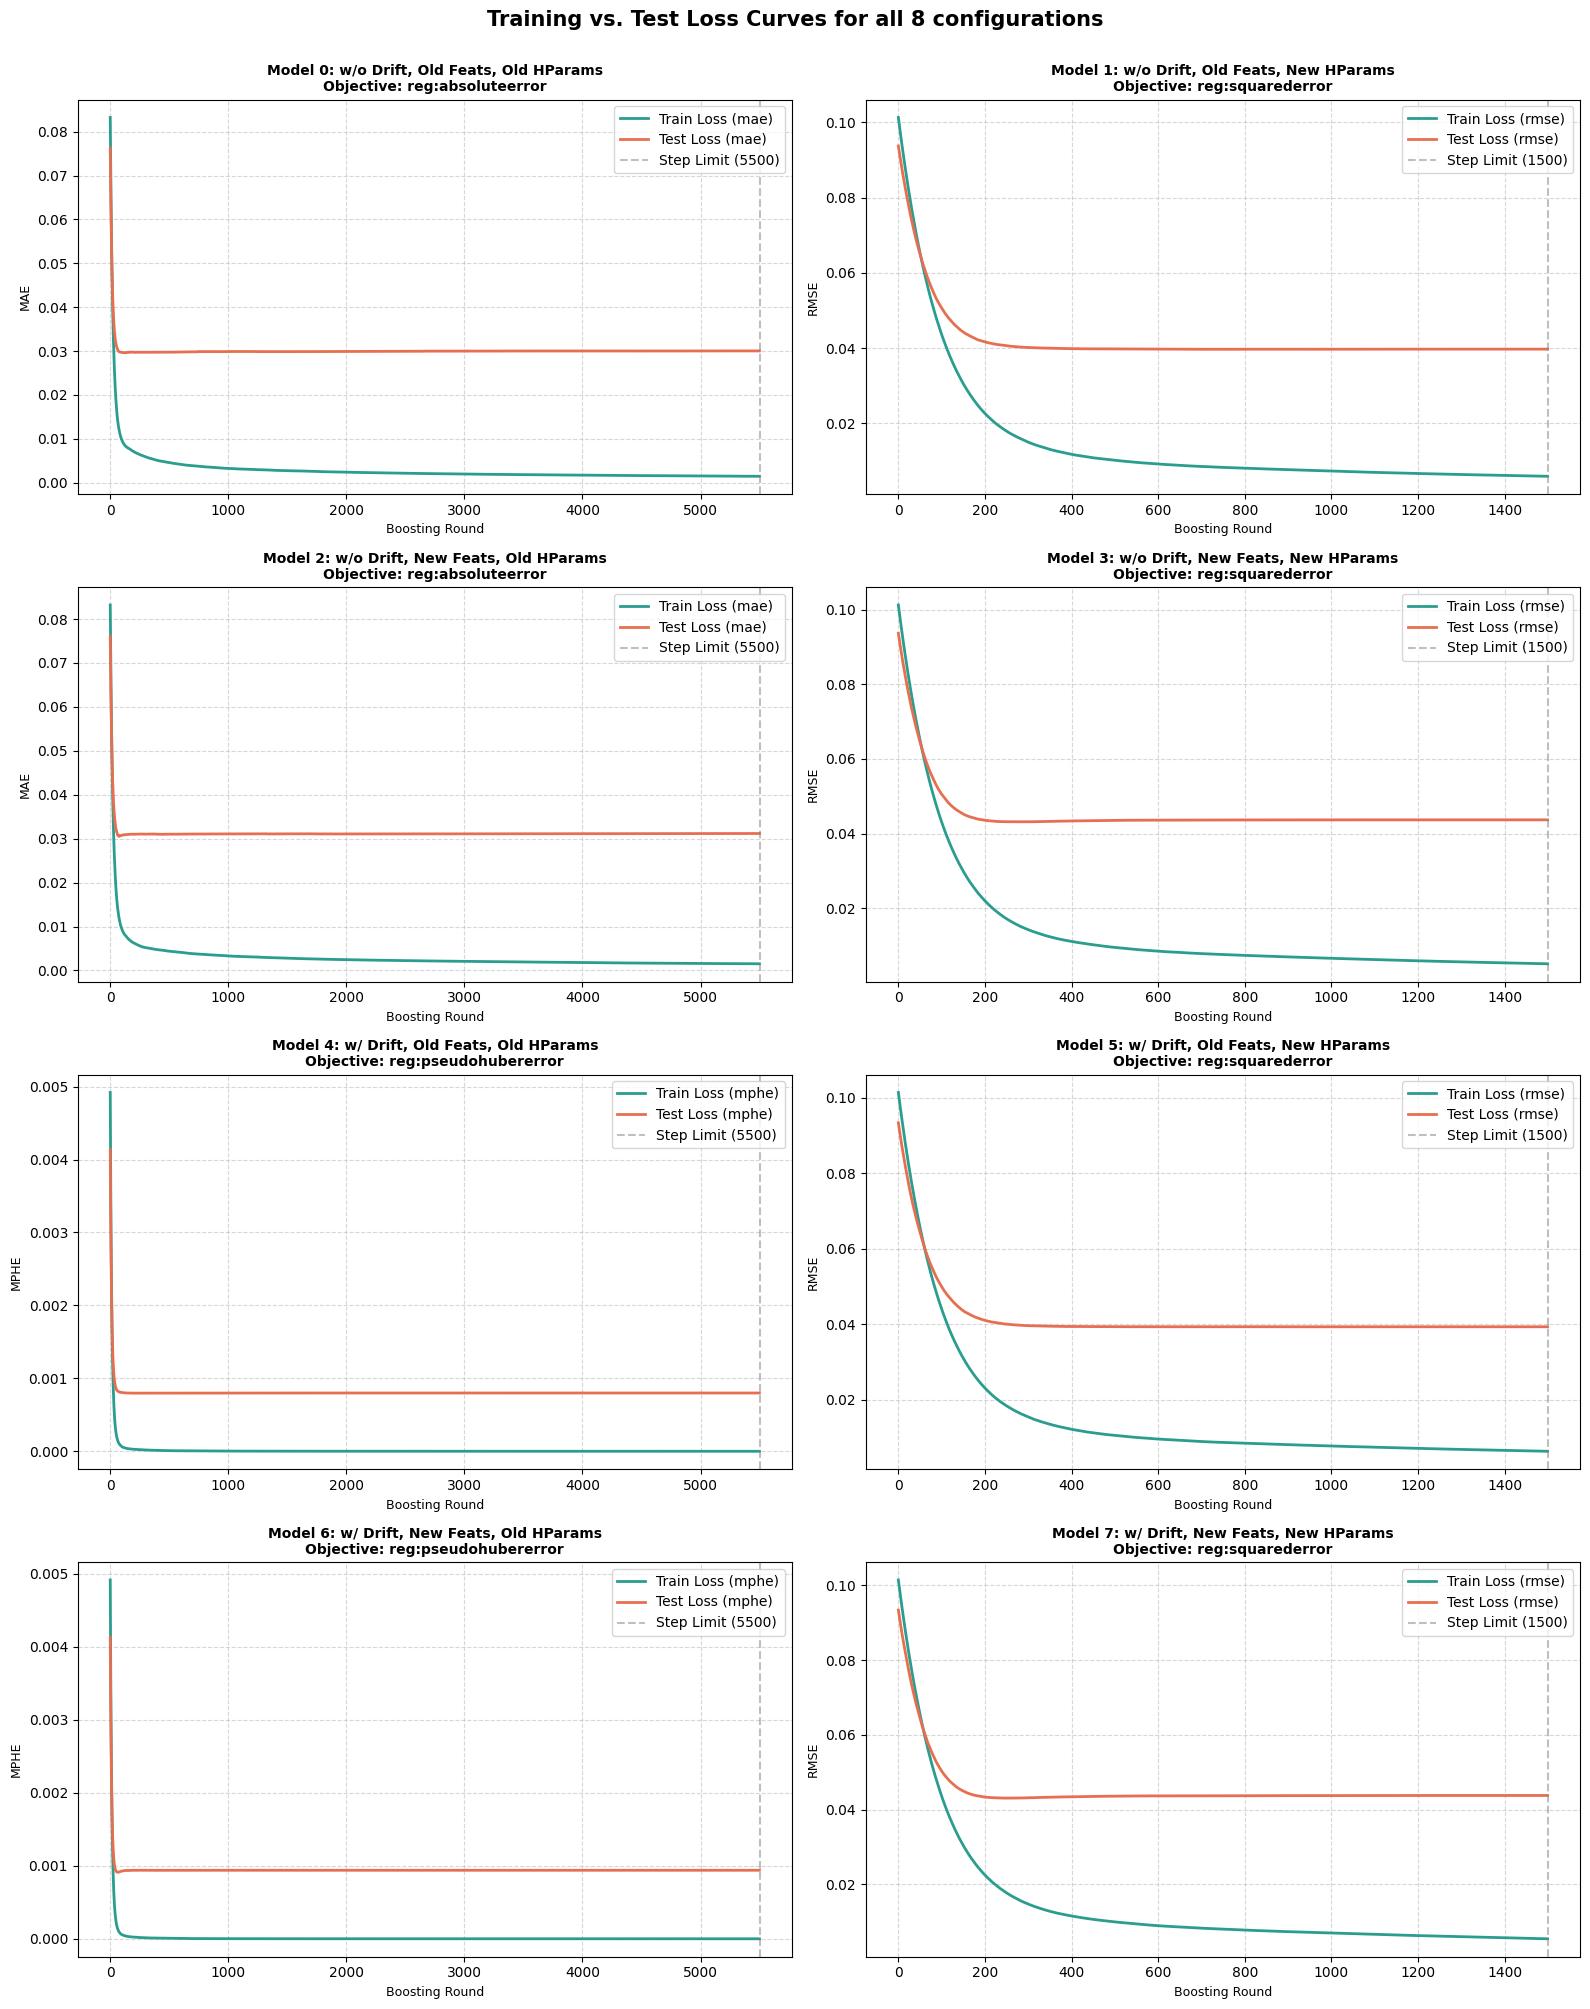

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

# Set standard colors for Train and Test
train_color = "#2a9d8f"
test_color = "#e76f51"

for i, mid in enumerate(sorted(evals_results.keys())):
    config = next(c for c in MODELS_CONFIG if c["id"] == mid)
    model_name = config["name"]
    evals = evals_results[mid]
    
    # Find the metric key dynamically (depends on objective: rmse, mae, or mphe)
    metric_key = list(evals["validation_0"].keys())[0]
    
    train_loss = evals["validation_0"][metric_key]
    val_loss = evals["validation_1"][metric_key]
    
    ax = axes[i]
    ax.plot(train_loss, label=f"Train Loss ({metric_key})", color=train_color, linewidth=2)
    ax.plot(val_loss, label=f"Test Loss ({metric_key})", color=test_color, linewidth=2)
    
    # Add vertical line at 1500 estimators for new hyperparameters models to highlight their early stopping or size
    n_est = config["hparams"]["n_estimators"]
    ax.axvline(x=n_est, color="gray", linestyle="--", alpha=0.5, label=f"Step Limit ({n_est})")
    
    ax.set_xlabel("Boosting Round", fontsize=9)
    ax.set_ylabel(metric_key.upper(), fontsize=9)
    ax.set_title(f"Model {mid}: {model_name}\nObjective: {config['hparams']['objective']}", fontsize=10, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right")

plt.suptitle("Training vs. Test Loss Curves for all 8 configurations", fontsize=15, fontweight="bold", y=1.002)
plt.tight_layout()
plt.savefig(OUT_DIR / "loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()